In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import os
import re
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import mc_test, boxm_test, update_chem_ds
from pycontrails.models.gpat.pp_gpat import GPATPostProcessor

In [2]:
outputs_dir = "/projects/Impact_of_aviation_on_climate/Kieran2024/outputs/" 
# outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        "job_id": "bg_run"
        # "job_id": [
        # 'bg_run_NA_2022-01-01T12_00_00',
        # 'bg_run_NA_2022-02-01T12_00_00',
        # 'bg_run_NA_2022-03-01T12_00_00',
        # 'bg_run_NA_2022-04-01T12_00_00',
        # 'bg_run_NA_2022-05-01T12_00_00',
        # 'bg_run_NA_2022-06-01T12_00_00',
        # 'bg_run_NA_2022-07-01T12_00_00',
        # 'bg_run_NA_2022-08-01T12_00_00',
        # 'bg_run_NA_2022-09-01T12_00_00',
        # 'bg_run_NA_2022-10-01T12_00_00',
        # 'bg_run_NA_2022-11-01T12_00_00',
        # 'bg_run_NA_2022-12-01T12_00_00'
        # ]

    }

In [4]:
pp_gpat = GPATPostProcessor(outputs_dir, criteria)
pp_gpat.filtered_df


,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,traj_gen_proc,gen_met_proc,bg_chem_proc,ac_perf_proc,emissions_proc,sim_plumes_proc,plume_to_grid_proc,run_cc_proc,run_boxm_proc,gen_outputs_proc
job_id,,,,,,,,,,,,,,,,,,,,,
bg_run_NA_2022-12-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000009,0.197508,0.273660,0.000004,0.000002,0.000002,0.115582,0.000002,0.564386,0
bg_run_US_2022-06-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000010,0.213227,0.276903,0.000004,0.000002,0.000006,0.121922,0.000002,0.507217,0
bg_run_EU_2022-01-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000010,0.212305,0.287411,0.000004,0.000002,0.000002,0.117693,0.000002,0.499965,0
bg_run_EU_2022-09-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000011,0.214074,0.291251,0.000004,0.000002,0.000003,0.121181,0.000002,0.577398,0
bg_run_NA_2022-10-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000012,0.220049,0.295003,0.000004,0.000003,0.000002,0.124502,0.000002,0.523263,0
bg_run_SEA_2022-05-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000011,0.209711,0.299346,0.000004,0.000002,0.000002,0.121119,0.000002,0.511731,0
bg_run_EU_2022-06-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000010,0.213371,0.308871,0.000004,0.000002,0.000002,0.122316,0.000002,0.594762,0
bg_run_SA_2022-08-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000010,0.203529,0.280654,0.000004,0.000002,0.000002,0.125029,0.000002,0.553586,0
bg_run_EU_2022-10-01T12_00_00,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",0,0 days 00:02:00,...,0.000009,0.196350,0.277124,0.000004,0.000002,0.000002,0.116110,0.000002,0.491951,0


In [5]:
# Create dicts to hold all necessary data (but no more)
chem_ds_dict = {}

In [6]:
# Check if the dictionary file exists
if os.path.exists(outputs_dir + 'chem_ds_dict.pkl'):
    # Load the dictionary from the file
    with open(outputs_dir + 'chem_ds_dict.pkl', 'rb') as f:
        chem_ds_dict = pickle.load(f)
    print("Loaded chem_ds_dict from file.")
else:
    # Initialize the dictionary
    chem_ds_dict = {}
    
    # Load the data
    for job_id in pp_gpat.job_ids:
        chem_ds_dict[job_id] = pp_gpat.load_chem_ds(job_id)

    # Save the dictionary to a file
    with open(outputs_dir + 'chem_ds_dict.pkl', 'wb') as f:
        pickle.dump(chem_ds_dict, f)
    print("Saved chem_ds_dict to file.")


chem_ds_dict


Loaded chem_ds_dict from file.


{'bg_run_NA_2022-12-01T12_00_00': <xarray.Dataset> Size: 69MB
 Dimensions:          (job_id: 1, longitude: 3, latitude: 3, time: 21601,
                       species: 219, emi_species: 9, photol_params: 5,
                       photol_coeffs: 5, therm_coeffs: 5, species_out: 14)
 Coordinates:
   * job_id           (job_id) object 8B 'bg_run_NA_2022-12-01T12_00_00'
     level            float64 8B 178.6
   * longitude        (longitude) float64 24B -33.0 -32.5 -32.0
   * latitude         (latitude) float64 24B 47.0 47.5 48.0
   * time             (time) datetime64[ns] 173kB 2022-12-01T12:00:00 ... 2022...
     air_pressure     (longitude, latitude) float64 72B ...
     altitude         (longitude, latitude) float64 72B ...
   * species          (species) <U10 9kB 'O1D' 'O' 'OH' ... 'EMPOA' 'P2007'
   * emi_species      (emi_species) <U7 252B 'NO' 'NO2' 'CO' ... 'C2H2' 'BENZENE'
   * species_out      (species_out) <U5 280B 'O3' 'NO2' 'NO' ... 'CH4' 'CH3O2'
 Dimensions without coordinat

In [7]:
# chem_ds_key = list(chem_ds_dict.keys())[0]
# chem_ds = chem_ds_dict[chem_ds_key]

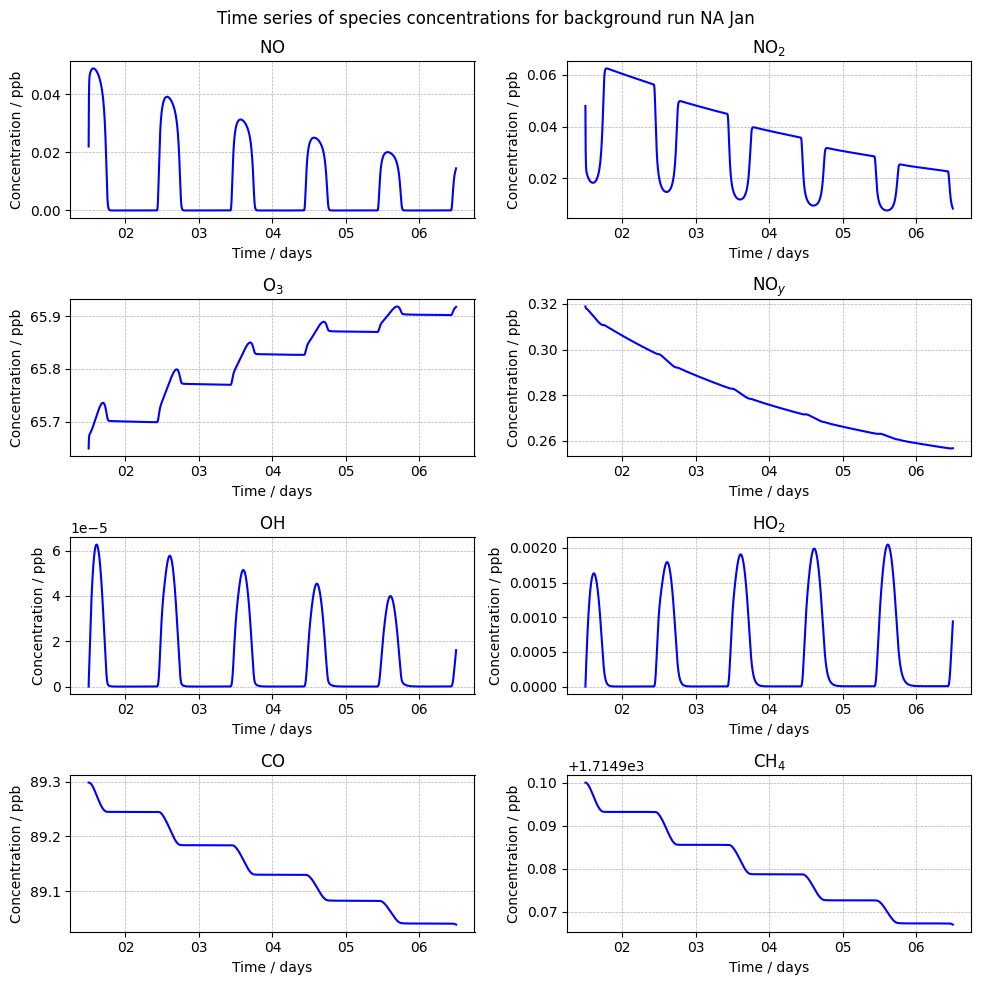

In [8]:
# bg run conc time series plots
fig, ax = plt.subplots(4, 2, figsize=(10, 10))

chem_ds = chem_ds_dict['bg_run_NA_2022-01-01T12_00_00']
chem_ds = pp_gpat.calc_cell(chem_ds, 1, 1)
chem_ds = chem_ds.isel(job_id=0)

# get time var
time = chem_ds["time"].values

# get month from time var
month = pd.to_datetime(time).month

# species to plot
NO = chem_ds["Y"].sel(species_out="NO").values
NO2 = chem_ds["Y"].sel(species_out="NO2").values
NOx = NO + NO2
O3 = chem_ds["Y"].sel(species_out="O3").values
OH = chem_ds["Y"].sel(species_out="OH").values
HO2 = chem_ds["Y"].sel(species_out="HO2").values
CO = chem_ds["Y"].sel(species_out="CO").values
CH4 = chem_ds["Y"].sel(species_out="CH4").values

NOy = pp_gpat.calc_NOy(chem_ds)
NOz = pp_gpat.calc_NOz(chem_ds)

NOPR = pp_gpat.calc_NOPR(chem_ds)
NO2t = pp_gpat.calc_NO2t(chem_ds)
O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds)

labels = {
    "NO": r'$\text{NO}$',
    "NO2": r'$\text{NO}_2$',
    "O3": r'$\text{O}_3$',
    "NOy": r'$\text{NO}_y$',
    "OH": r'$\text{OH}$',
    "HO2": r'$\text{HO}_2$',
    "CO": r'$\text{CO}$',
    "CH4": r'$\text{CH}_4$'
}

pp_gpat.plot_line_plot(ax[0, 0], time, NO, labels["NO"], 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[0, 1], time, NO2, labels["NO2"], 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[1, 0], time, O3, labels["O3"], 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[1, 1], time, NOy, labels["NOy"], 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 0], time, OH, labels["OH"], 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 1], time, HO2, labels["HO2"], 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 0], time, CO, labels["CO"], 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 1], time, CH4, labels["CH4"], 'Time / days', 'Concentration / ppb')

#ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
fig.suptitle('Time series of species concentrations for background run NA Jan')
plt.tight_layout()
plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_concs_time_series.png")
plt.show()

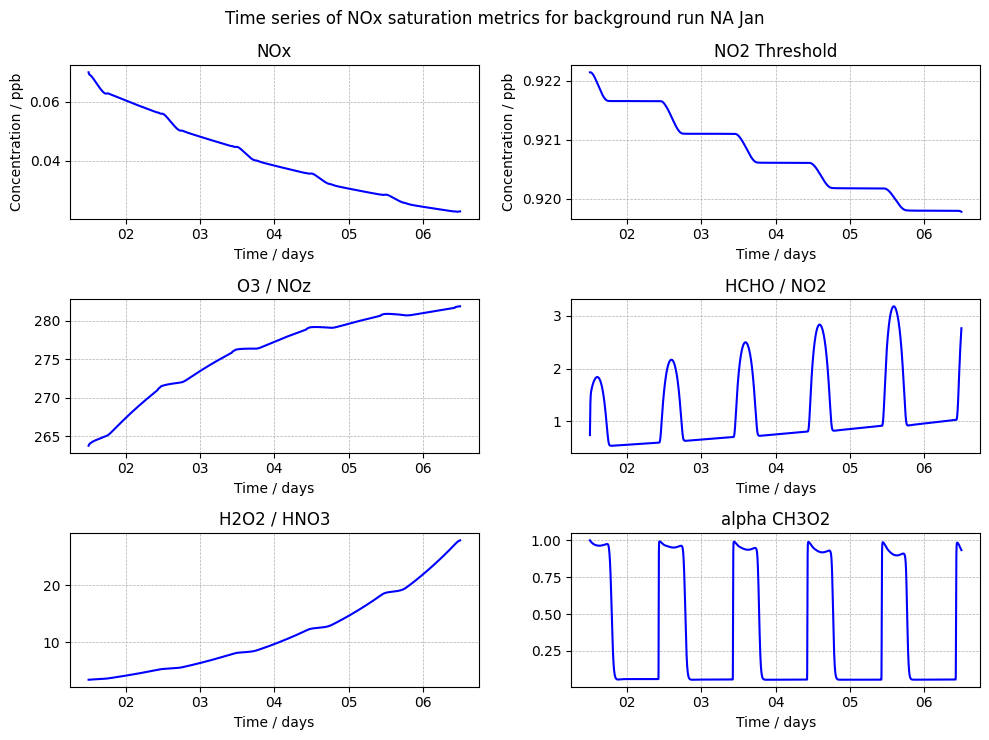

In [9]:
# bg run metric time series plots
fig, ax = plt.subplots(3, 2, figsize=(10, 7.5))

# get time var
time = chem_ds["time"].values

# get month from time var
month = pd.to_datetime(time).month

# species to plot
NO = chem_ds["Y"].sel(species_out="NO").values
NO2 = chem_ds["Y"].sel(species_out="NO2").values
NOx = NO + NO2
O3 = chem_ds["Y"].sel(species_out="O3").values
OH = chem_ds["Y"].sel(species_out="OH").values
HO2 = chem_ds["Y"].sel(species_out="HO2").values
CO = chem_ds["Y"].sel(species_out="CO").values
CH4 = chem_ds["Y"].sel(species_out="CH4").values

NOy = pp_gpat.calc_NOy(chem_ds)
NOz = pp_gpat.calc_NOz(chem_ds)

NOPR = pp_gpat.calc_NOPR(chem_ds)
NO2t = pp_gpat.calc_NO2t(chem_ds)
O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds) 

pp_gpat.plot_line_plot(ax[0, 0], time, NOx, 'NOx', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[0, 1], time, NO2t, 'NO2 Threshold', 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[1, 0], time, O3_NOz, 'O3 / NOz', 'Time / days', '') 
pp_gpat.plot_line_plot(ax[1, 1], time, HCHO_NO2, 'HCHO / NO2', 'Time / days', '')
pp_gpat.plot_line_plot(ax[2, 0], time, H2O2_HNO3, 'H2O2 / HNO3', 'Time / days', '')
pp_gpat.plot_line_plot(ax[2, 1], time, alpha_CH3O2, 'alpha CH3O2', 'Time / days', '')

# ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
fig.suptitle('Time series of NOx saturation metrics for background run NA Jan')
plt.tight_layout()
plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_metrics_time_series.png")
plt.show()



In [10]:
# Define the locations and their corresponding colors
locations = ["NA", "EU", "US", "SEA", "SA"]
colors = ['#1f77b4', '#66c2a5', '#ff7f0e', '#9467bd', '#d62728']  # Blue, Orange, Green, Purple, Red
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Initialize dictionaries to store the data for each metric
metrics = {
    "NOx": {loc: {month: [] for month in range(1, 13)} for loc in locations},
    "NO2t": {loc: {month: [] for month in range(1, 13)} for loc in locations},
    "O3 / NOz": {loc: {month: [] for month in range(1, 13)} for loc in locations},
    "HCHO / NO2": {loc: {month: [] for month in range(1, 13)} for loc in locations},
    "H2O2 / HNO3": {loc: {month: [] for month in range(1, 13)} for loc in locations},
    "alpha-CH3O2": {loc: {month: [] for month in range(1, 13)} for loc in locations}
}

labels = {
    "NOx": r'$\text{NO}_x$',
    "NO2t": r'$\text{NO}_2\text{t}$',
    "O3 / NOz": r'$\text{O}_3 / \text{NO}_z$',
    "HCHO / NO2": r'$\text{HCHO} / \text{NO}_2$',
    "H2O2 / HNO3": r'$\text{H}_2\text{O}_2 / \text{HNO}_3$',
    "alpha-CH3O2": r'$\alpha\text{-CH}_3\text{O}_2$'
}

run_path = "/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/"
data_path = "/projects/Impact_of_aviation_on_climate/Kieran2024/"
# Loop through each job and collect the data
for job_id, chem_ds in chem_ds_dict.items():
    for loc in locations:
        if loc in job_id:
            # Define chem ds as central cell (point analysis)
            chem_ds = pp_gpat.calc_cell(chem_ds, 1, 1)
            chem_ds = chem_ds.isel(job_id=0)
            
            # Get time var
            time = chem_ds["time"].values

            # Get month from time var
            month = pd.to_datetime(time).month[0]  # Get the first month

            # Species to plot
            NO = chem_ds["Y"].sel(species_out="NO").values
            NO2 = chem_ds["Y"].sel(species_out="NO2").values
            NOx = NO + NO2
            O3 = chem_ds["Y"].sel(species_out="O3").values
            OH = chem_ds["Y"].sel(species_out="OH").values
            HO2 = chem_ds["Y"].sel(species_out="HO2").values
            CO = chem_ds["Y"].sel(species_out="CO").values
            CH4 = chem_ds["Y"].sel(species_out="CH4").values

            NOy = pp_gpat.calc_NOy(chem_ds)
            NOz = pp_gpat.calc_NOz(chem_ds)

            NOx = NOx[21600]
            NO2t = pp_gpat.calc_NO2t(chem_ds).isel(time=21600)
            O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz).isel(time=21600)
            HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
            HCHO_NO2 = pp_gpat.calc_daytime_mean(HCHO_NO2, chem_ds)
            H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds).isel(time=21600)
            alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds)
            alpha_CH3O2 = pp_gpat.calc_daytime_mean(alpha_CH3O2, chem_ds)

            # Store the data in the metrics dictionary
            metrics["NOx"][loc][month].append(NOx)
            metrics["NO2t"][loc][month].append(NO2t)
            metrics["O3 / NOz"][loc][month].append(O3_NOz)
            metrics["HCHO / NO2"][loc][month].append(HCHO_NO2)
            metrics["H2O2 / HNO3"][loc][month].append(H2O2_HNO3)
            metrics["alpha-CH3O2"][loc][month].append(alpha_CH3O2)


            #chem_ds_dict[job_id] = boxm_test(run_path, data_path, job_id, chem_ds)


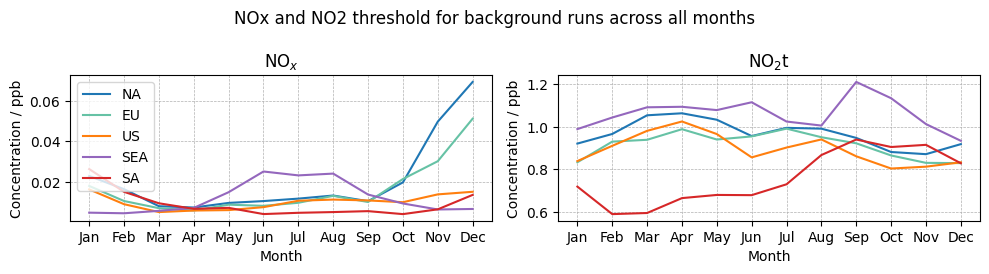

In [11]:
# Plot the first set of data (NOx and NO2t)
fig1, ax1 = plt.subplots(1, 2, figsize=(10, 2.75))

for i, metric in enumerate(["NOx", "NO2t"]):
    data = metrics[metric]
    label = labels[metric]
    for loc, color in zip(locations, colors):
        # Prepare the data for plotting
        y_values = [np.mean(data[loc][month]) for month in range(1, 13)]
        show_legend = (i == 0)  # Show legend only for the first subplot
        pp_gpat.plot_line_plot(ax1[i], months, y_values, metric, 'Month', 'Concentration / ppb', label=loc, color=color, show_legend=show_legend)
        ax1[i].set_title(label)
fig1.suptitle('NOx and NO2 threshold for background runs across all months')
plt.tight_layout()
plt.savefig(f"{outputs_dir}/plots/bg_run_NO2t_months.png")
plt.show()

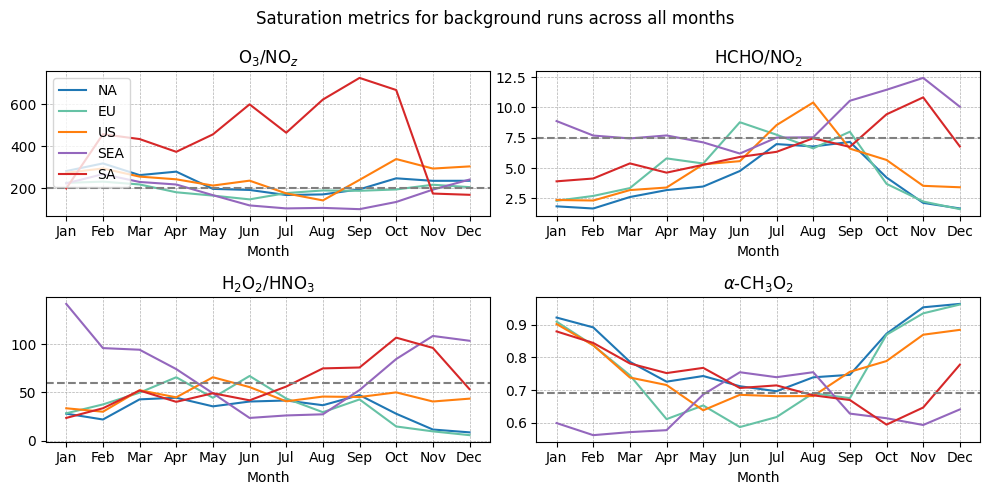

In [12]:
# Plot the second set of data (O3_NOz, HCHO_NO2, H2O2_HNO3, alpha_CH3O2)
fig2, ax2 = plt.subplots(2, 2, figsize=(10, 5))

for i, metric in enumerate(["O3 / NOz", "HCHO / NO2", "H2O2 / HNO3", "alpha-CH3O2"]):

    if metric == "O3 / NOz":
        demarcation = 200
    elif metric == "HCHO / NO2":
        demarcation = 7.5
    elif metric == "H2O2 / HNO3":
        demarcation = 60
    elif metric == "alpha-CH3O2":
        demarcation = 0.69

    row, col = divmod(i, 2)
    data = metrics[metric]
    label = labels[metric]
    for loc, color in zip(locations, colors):
        # Prepare the data for plotting
        y_values = [np.mean(data[loc][month]) for month in range(1, 13)]
        show_legend = (i == 0)  # Show legend only for the first subplot
        pp_gpat.plot_line_plot(ax2[row, col], months, y_values, metric, 'Month', '', label=loc, color=color, show_legend=show_legend)
    # Plot the horizontal dashed line at the demarcation
    ax2[row, col].axhline(y=demarcation, color='gray', linestyle='--')
    ax2[row, col].set_title(label)

fig2.suptitle('Saturation metrics for background runs across all months')
plt.tight_layout()
plt.savefig(f"{outputs_dir}/plots/bg_run_metrics_months.png")
plt.show()

bg_run_NA_2022-12-01T12_00_00


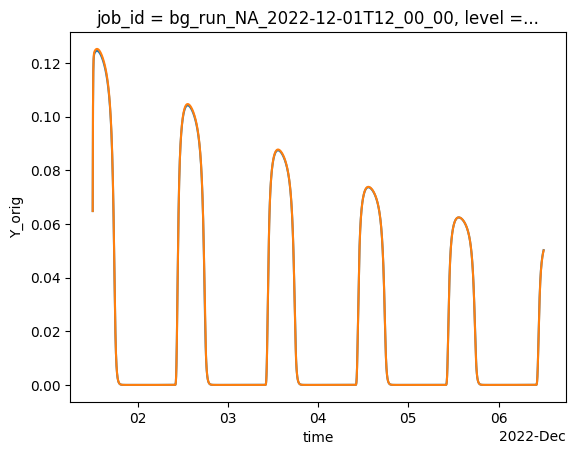

bg_run_US_2022-06-01T12_00_00


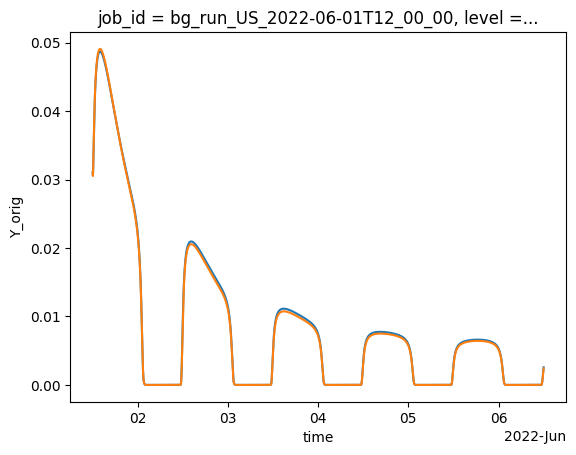

bg_run_EU_2022-01-01T12_00_00


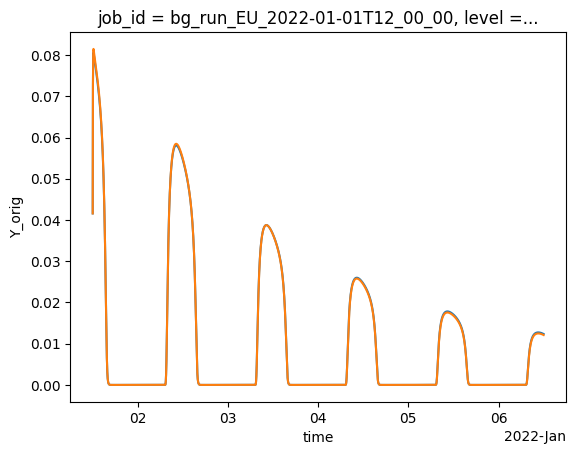

bg_run_EU_2022-09-01T12_00_00


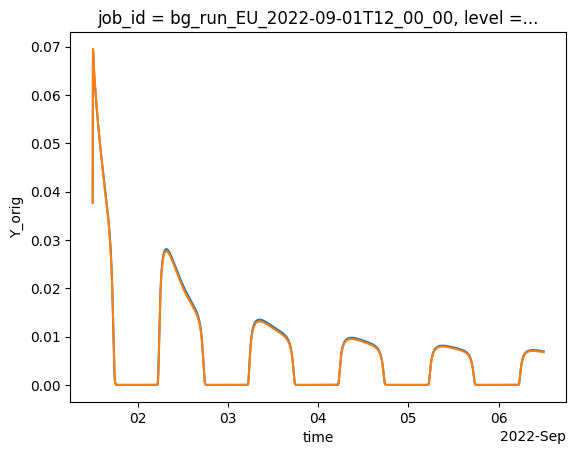

bg_run_NA_2022-10-01T12_00_00


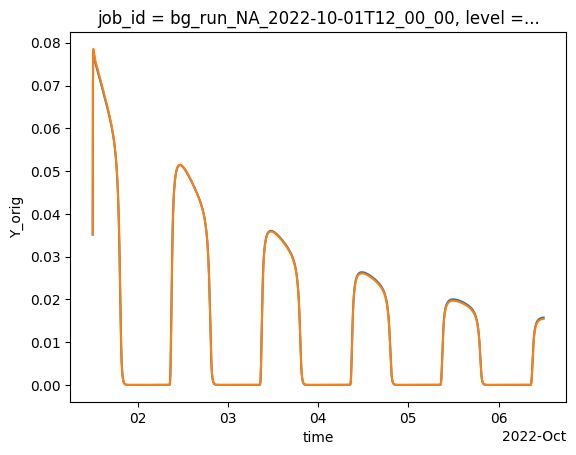

bg_run_SEA_2022-05-01T12_00_00


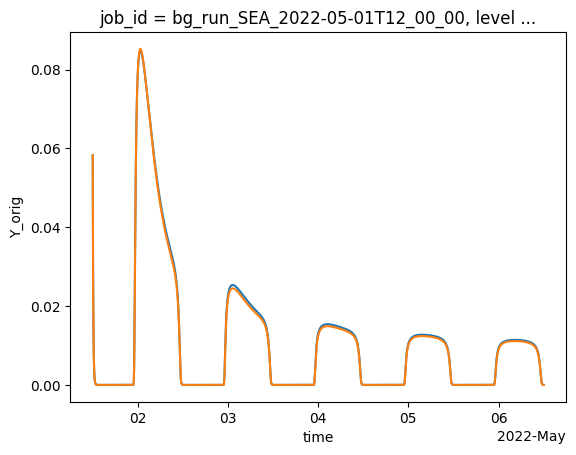

bg_run_EU_2022-06-01T12_00_00


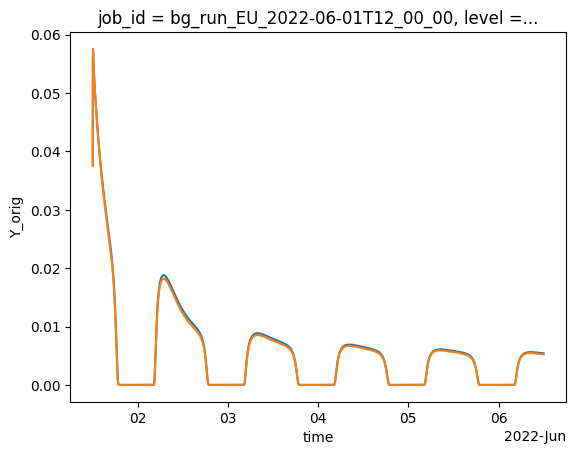

bg_run_SA_2022-08-01T12_00_00


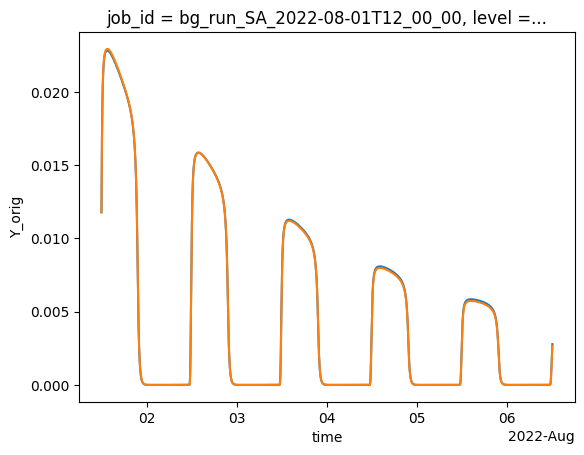

bg_run_EU_2022-10-01T12_00_00


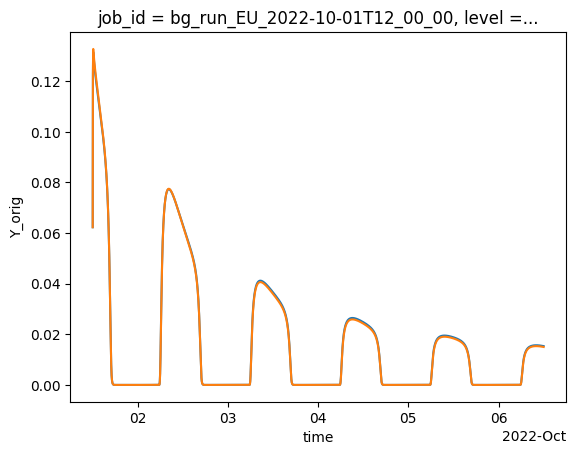

bg_run_NA_2022-03-01T12_00_00


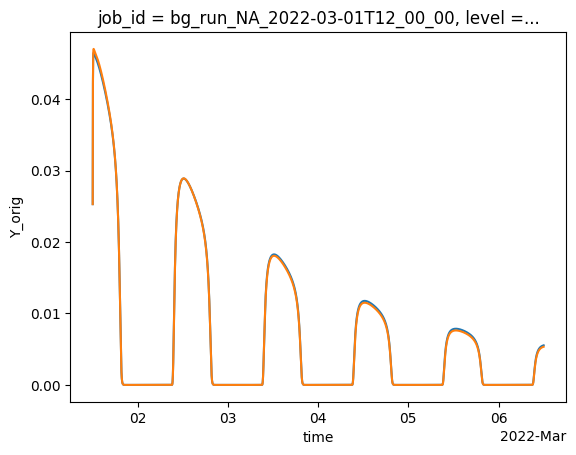

bg_run_SA_2022-07-01T12_00_00


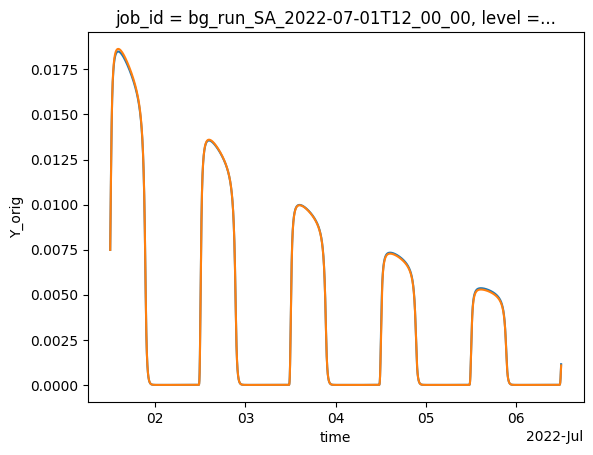

bg_run_SEA_2022-04-01T12_00_00


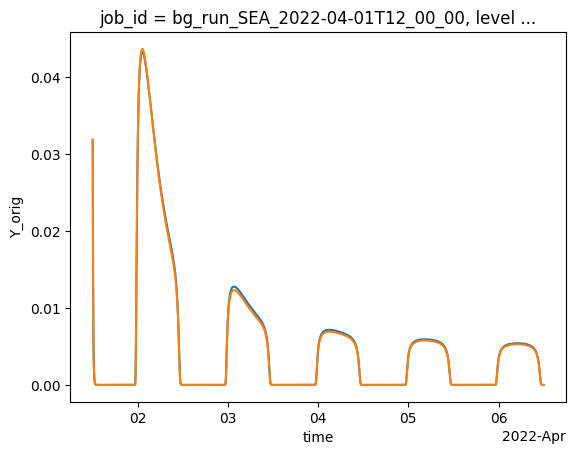

bg_run_SEA_2022-08-01T12_00_00


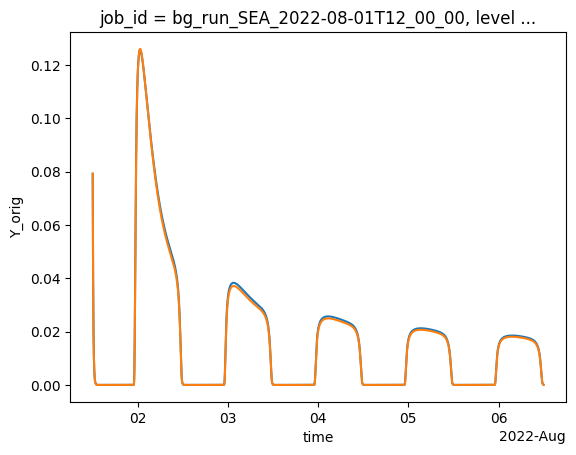

bg_run_NA_2022-07-01T12_00_00


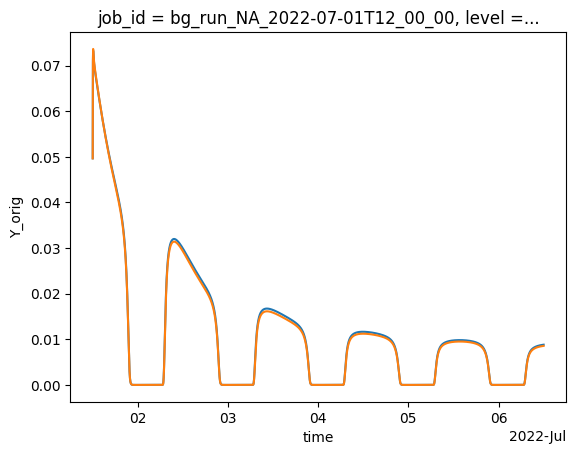

bg_run_US_2022-09-01T12_00_00


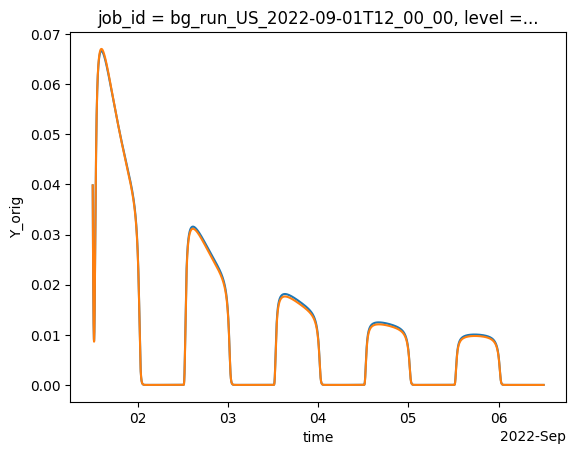

bg_run_SA_2022-02-01T12_00_00


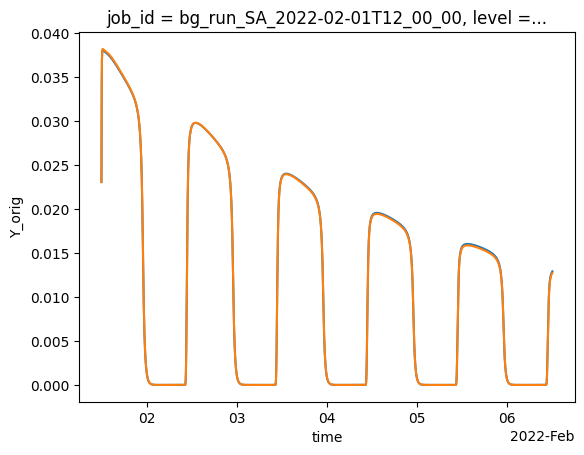

bg_run_US_2022-11-01T12_00_00


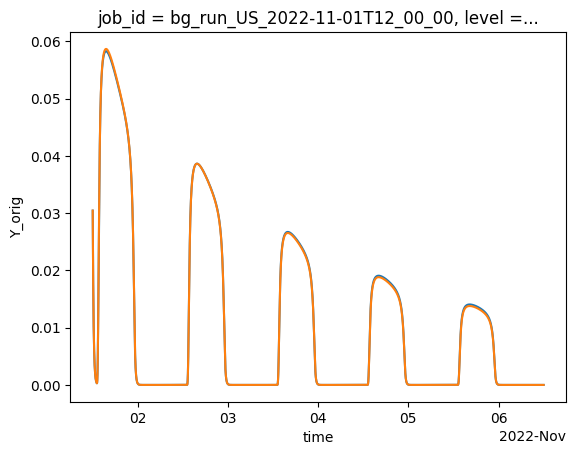

bg_run_EU_2022-02-01T12_00_00


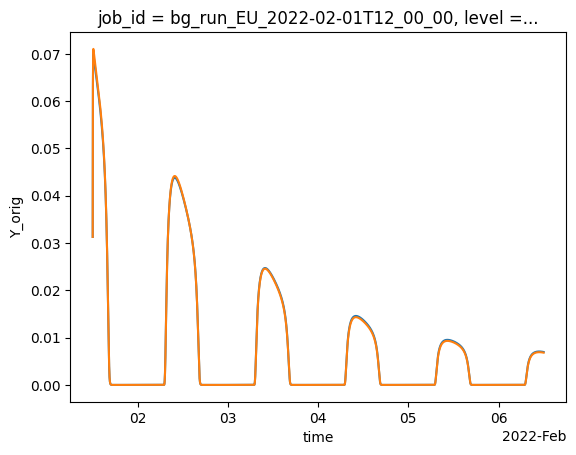

bg_run_SEA_2022-03-01T12_00_00


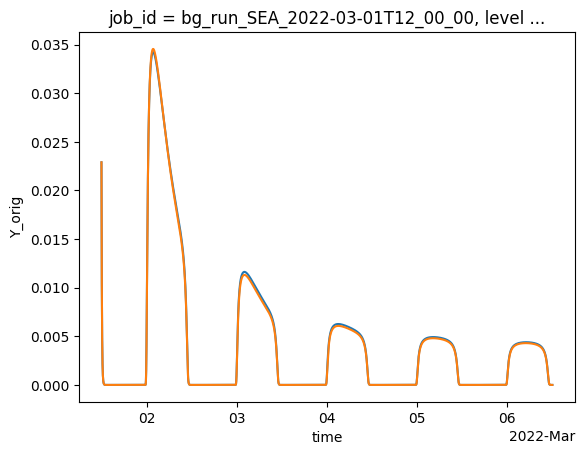

bg_run_EU_2022-07-01T12_00_00


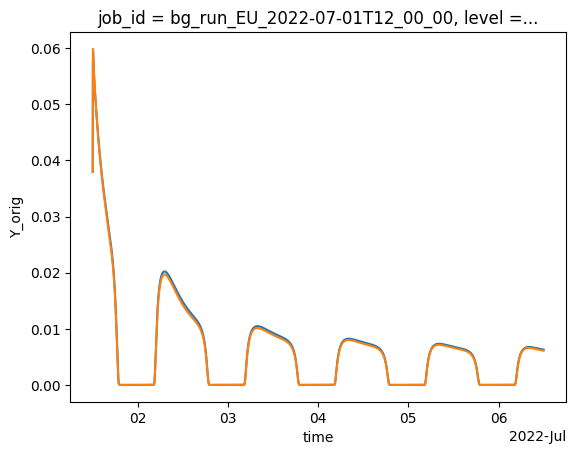

bg_run_SEA_2022-07-01T12_00_00


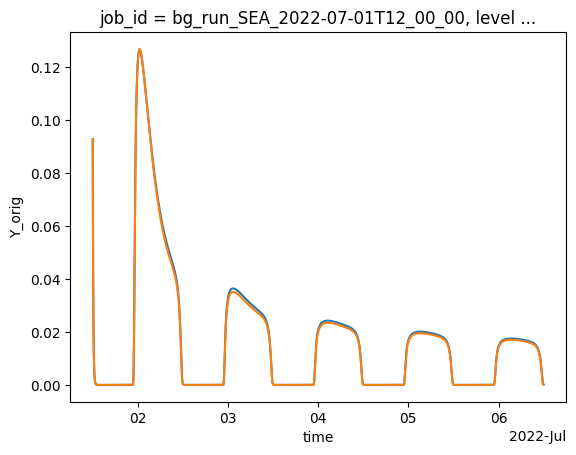

bg_run_SEA_2022-10-01T12_00_00


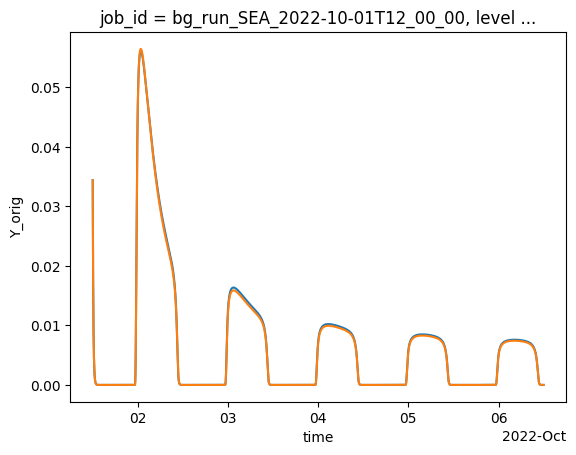

bg_run_SA_2022-11-01T12_00_00


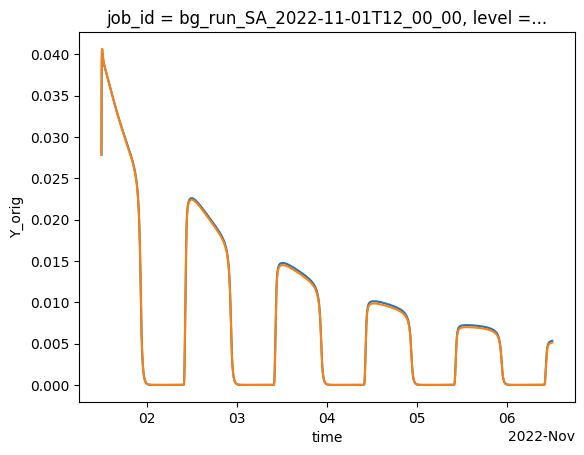

bg_run_SA_2022-03-01T12_00_00


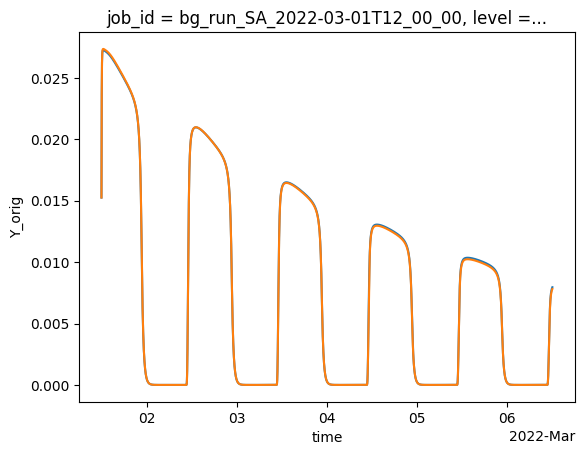

bg_run_SA_2022-04-01T12_00_00


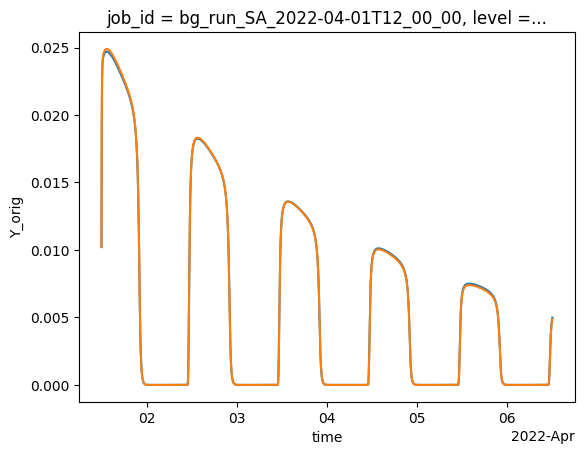

bg_run_NA_2022-08-01T12_00_00


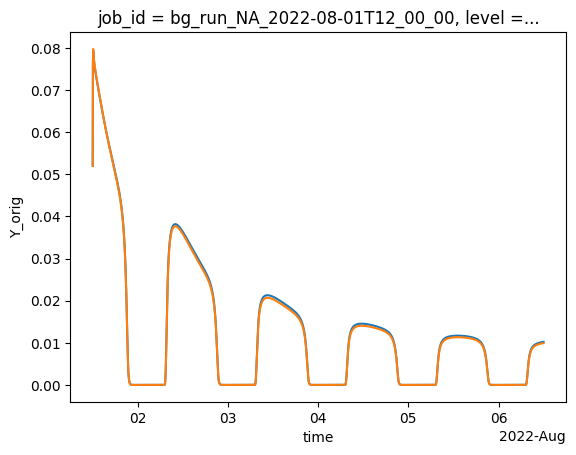

bg_run_US_2022-02-01T12_00_00


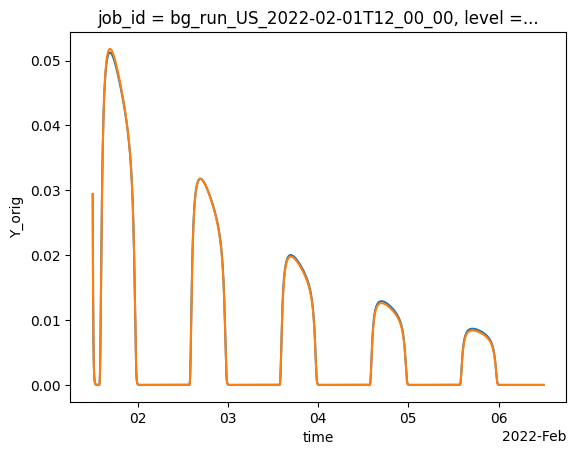

bg_run_US_2022-01-01T12_00_00


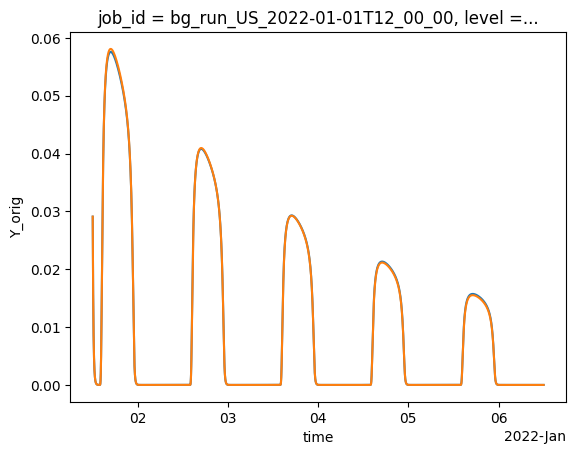

bg_run_US_2022-05-01T12_00_00


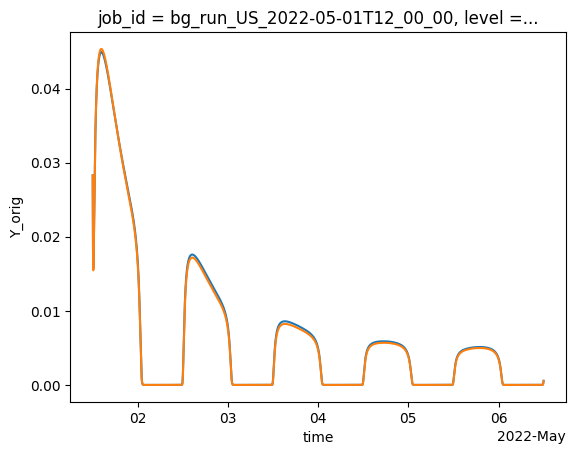

bg_run_NA_2022-05-01T12_00_00


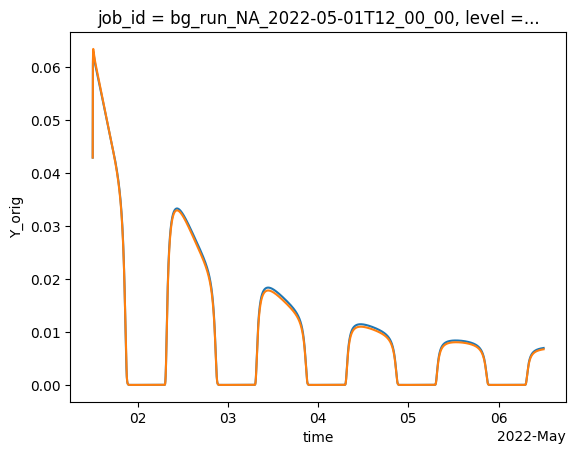

bg_run_SEA_2022-01-01T12_00_00


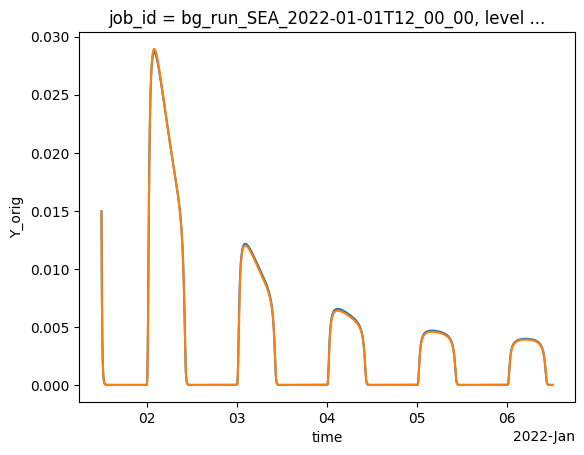

bg_run_US_2022-08-01T12_00_00


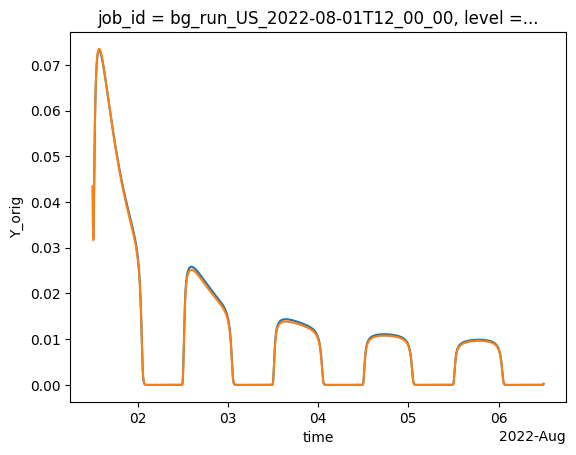

bg_run_SEA_2022-06-01T12_00_00


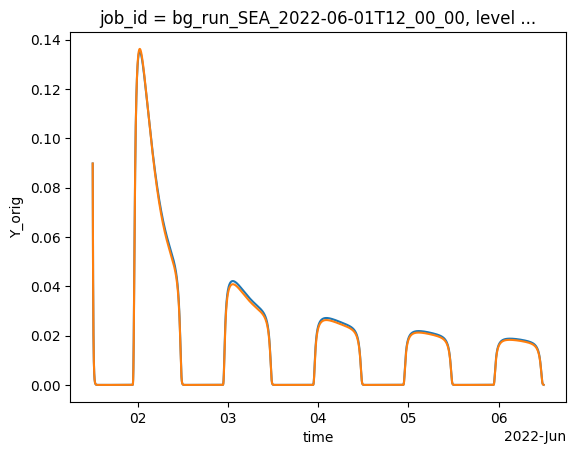

bg_run_US_2022-07-01T12_00_00


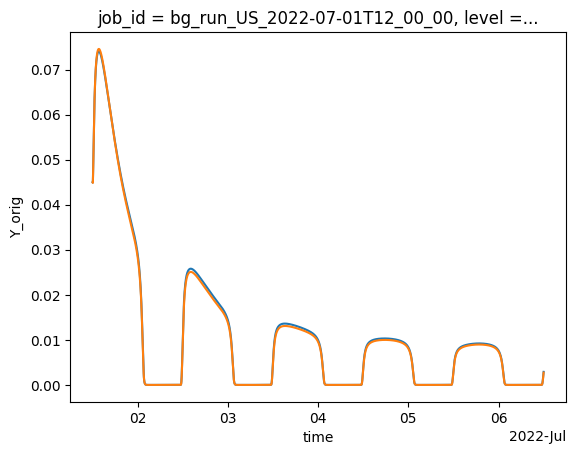

bg_run_NA_2022-11-01T12_00_00


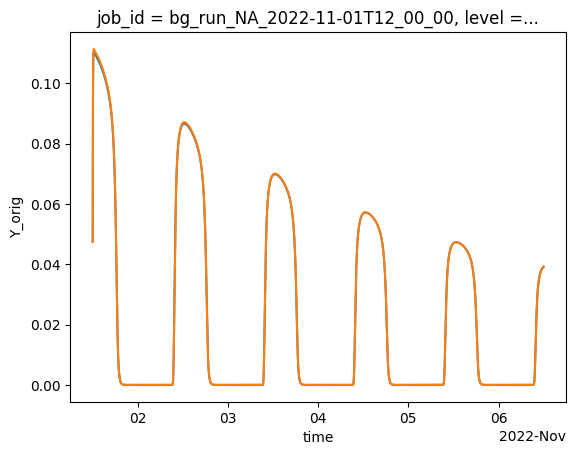

bg_run_NA_2022-06-01T12_00_00


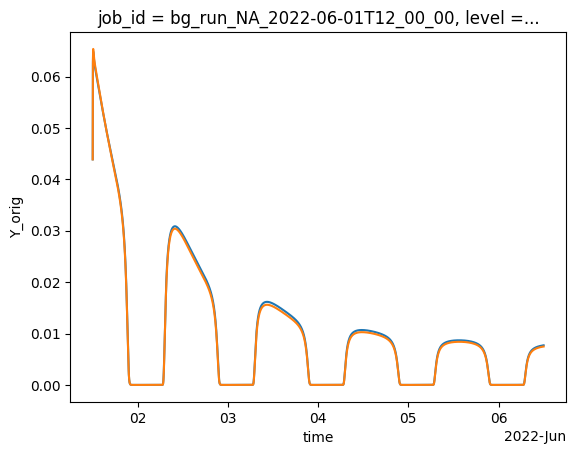

bg_run_EU_2022-04-01T12_00_00


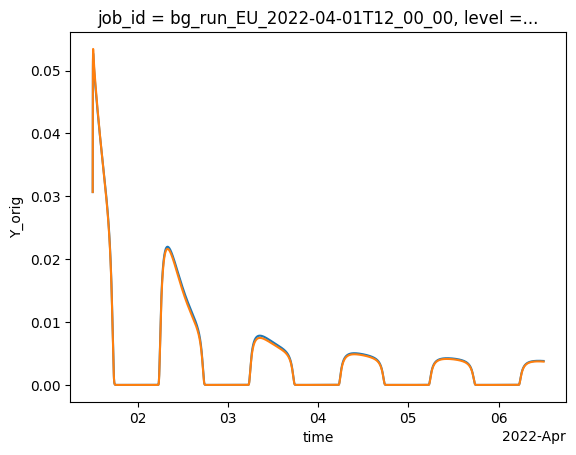

bg_run_NA_2022-01-01T12_00_00


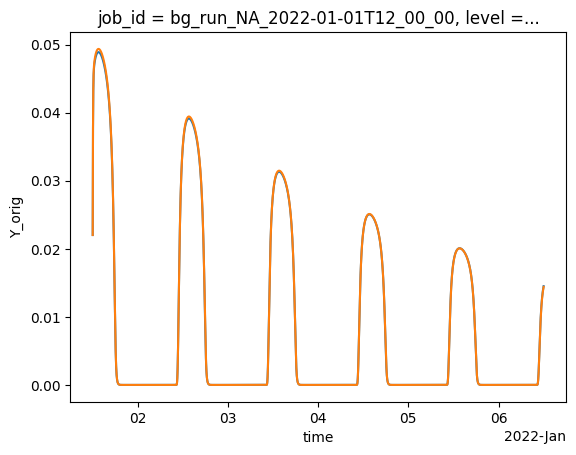

bg_run_SA_2022-09-01T12_00_00


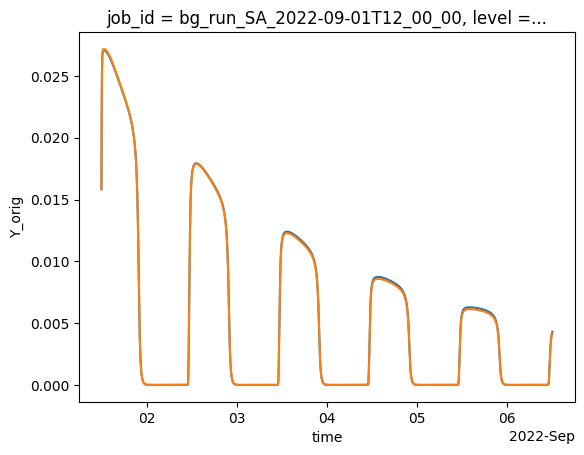

bg_run_US_2022-04-01T12_00_00


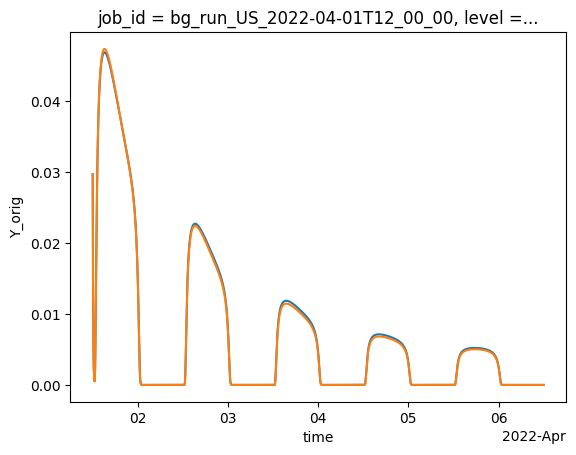

bg_run_SEA_2022-09-01T12_00_00


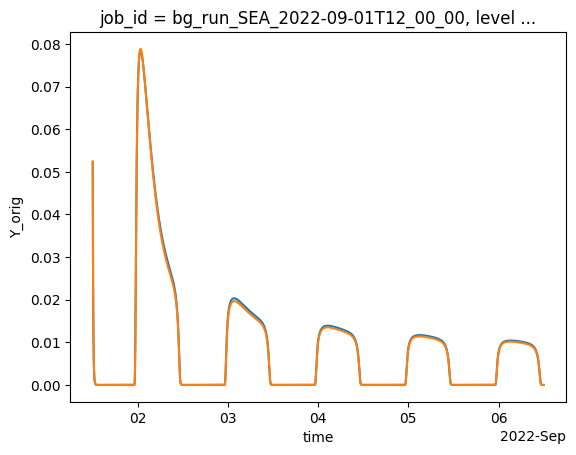

bg_run_NA_2022-02-01T12_00_00


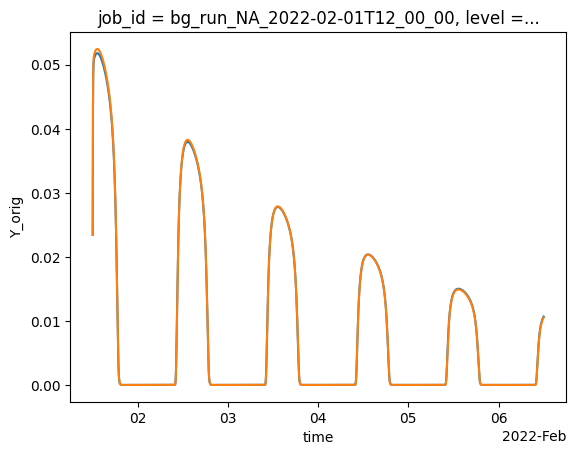

bg_run_SEA_2022-12-01T12_00_00


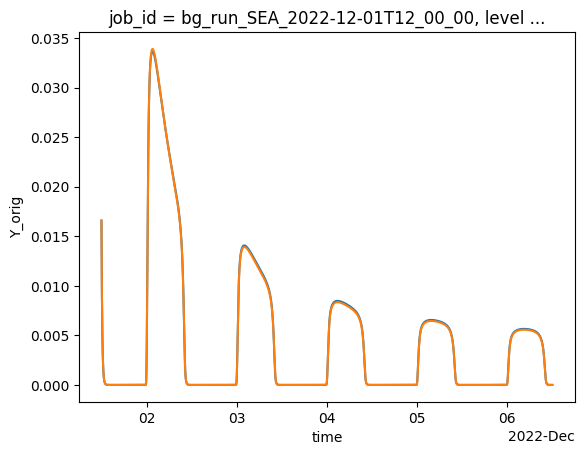

bg_run_SA_2022-01-01T12_00_00


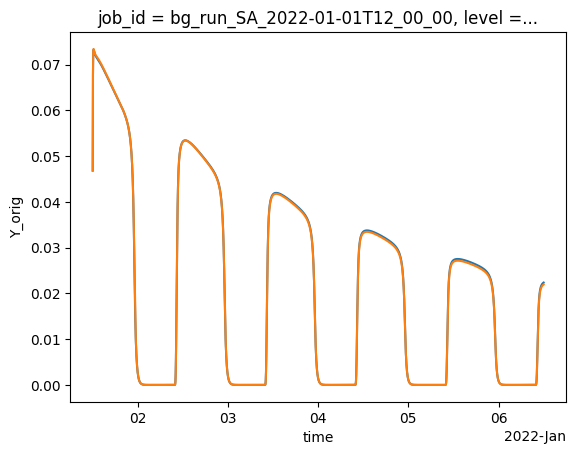

bg_run_US_2022-12-01T12_00_00


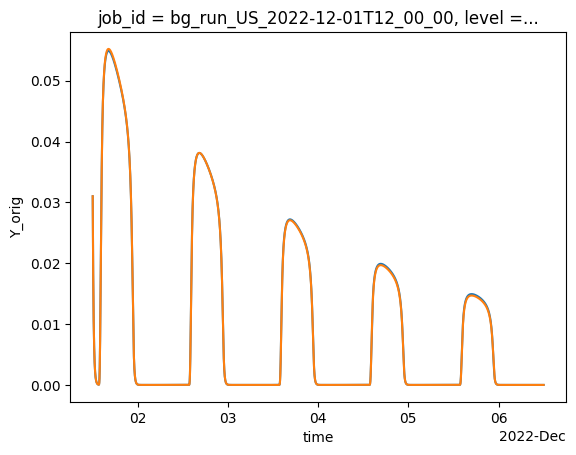

bg_run_SA_2022-12-01T12_00_00


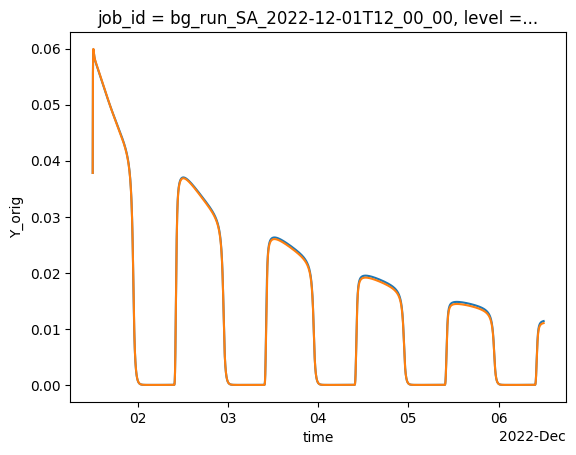

bg_run_SA_2022-10-01T12_00_00


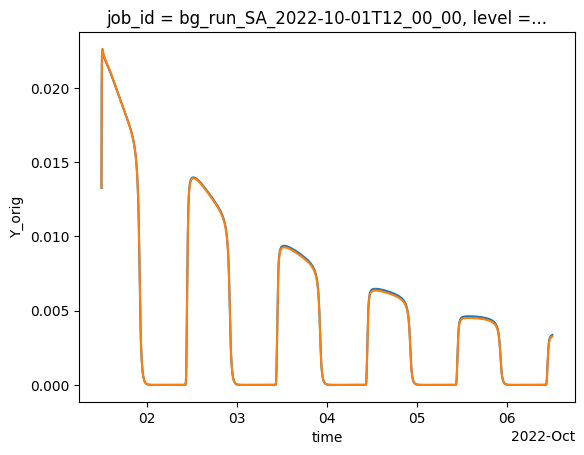

bg_run_EU_2022-11-01T12_00_00


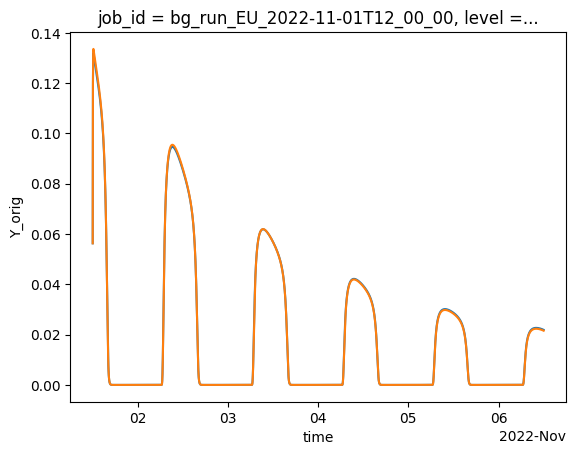

bg_run_NA_2022-09-01T12_00_00


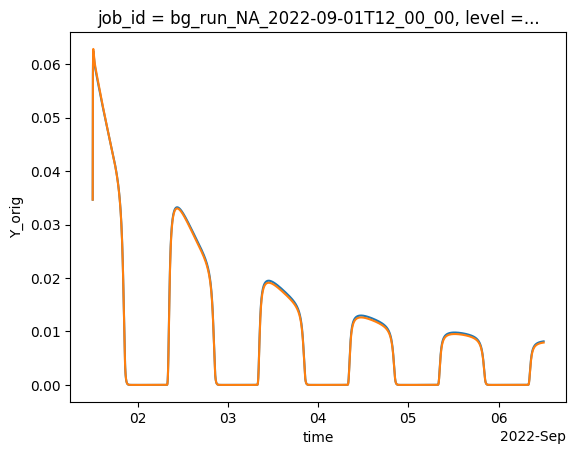

bg_run_US_2022-10-01T12_00_00


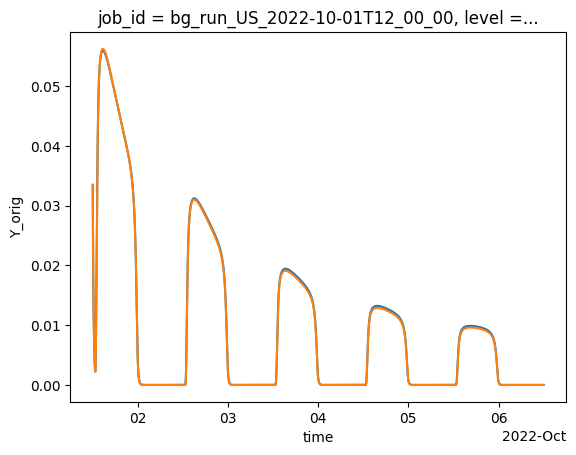

bg_run_NA_2022-04-01T12_00_00


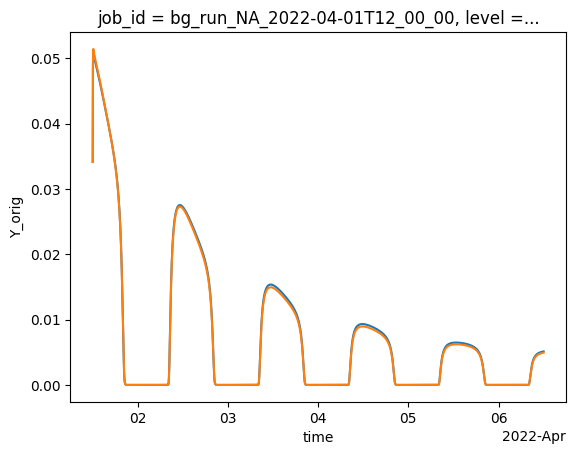

bg_run_EU_2022-12-01T12_00_00


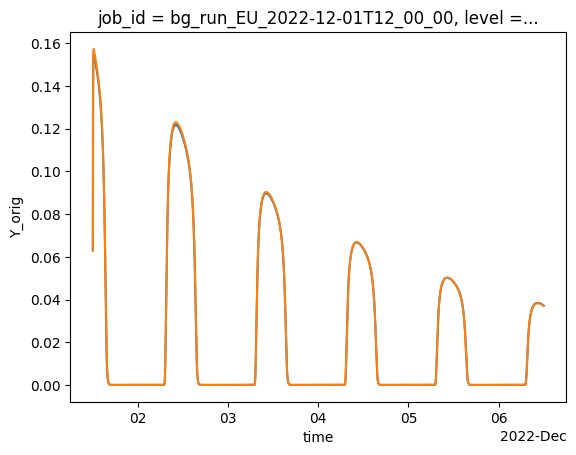

bg_run_SEA_2022-02-01T12_00_00


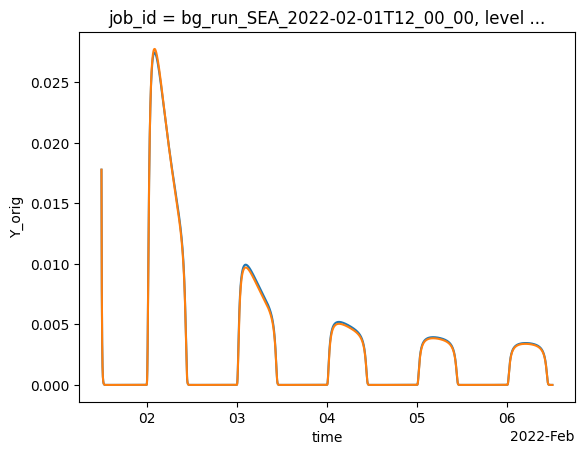

bg_run_US_2022-03-01T12_00_00


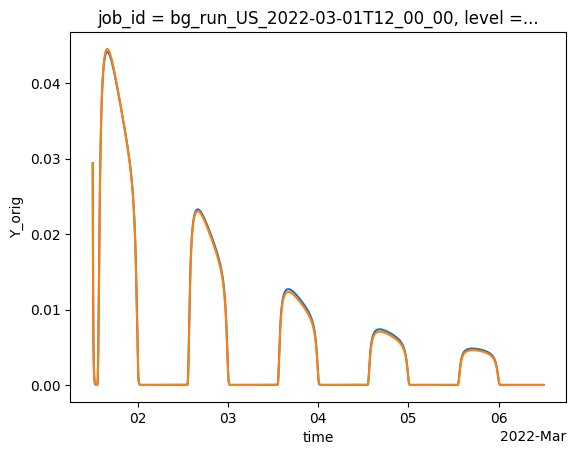

bg_run_EU_2022-03-01T12_00_00


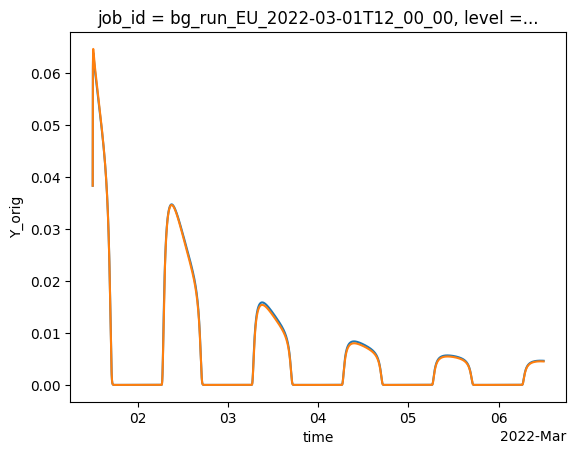

bg_run_EU_2022-05-01T12_00_00


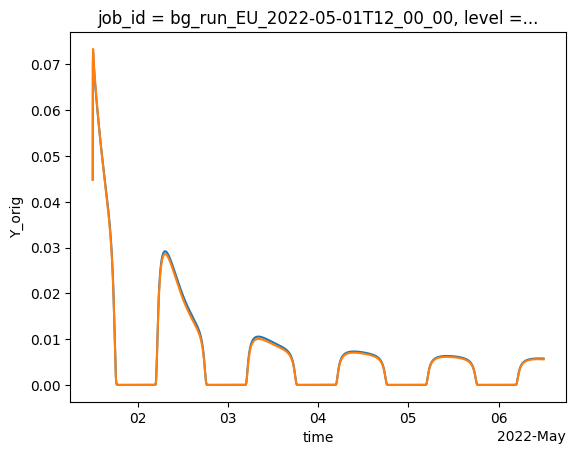

bg_run_SA_2022-05-01T12_00_00


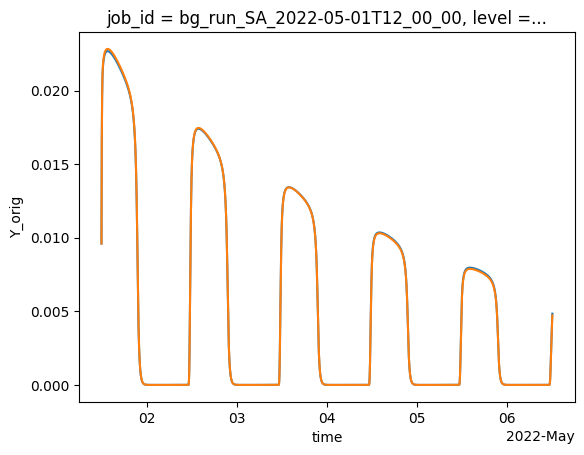

bg_run_SA_2022-06-01T12_00_00


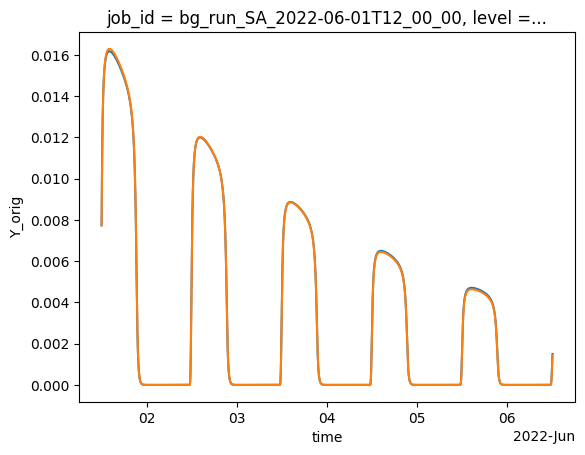

bg_run_EU_2022-08-01T12_00_00


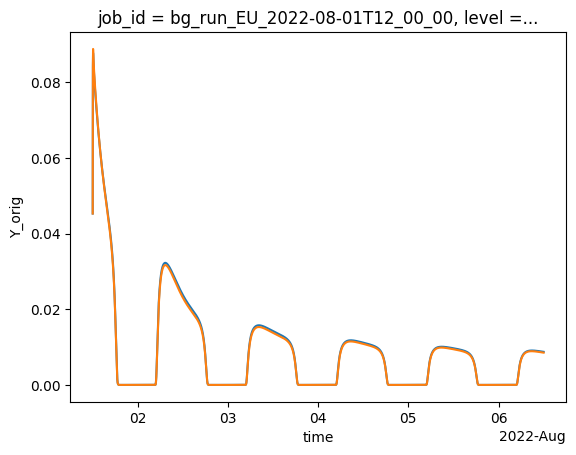

bg_run_SEA_2022-11-01T12_00_00


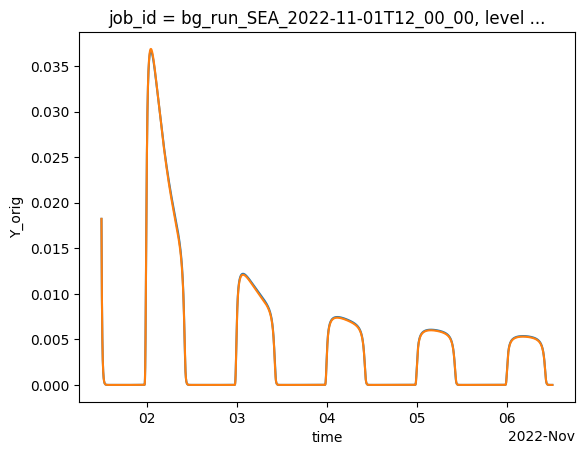

In [24]:
for job_id, chem_ds in chem_ds_dict.items():
    print(job_id)

    chem_ds = pp_gpat.calc_cell(chem_ds, 1, 1)
    chem_ds = chem_ds.isel(job_id=0)
    chem_ds = update_chem_ds(data_path, chem_ds, job_id)
    chem_data = chem_ds["Y"].sel(species_out="NO")
    chem_orig_data = chem_ds["Y_orig"].sel(species_out="NO").compute()
    #print(chem_data)
    chem_data.plot()
    chem_orig_data.plot()
    plt.show()


In [ ]:
# chem_da = []
# emi_da = []
# # Create a figure and axis for plotting
# fig, ax = plt.subplots(figsize=(10, 6))

# for job, ds in enumerate(chem_ds):
#     chem_ds[job] = chem_ds[job].assign_coords(species_out=chem_ds[job].attrs["species_out"])
#     chem_da.append(chem_ds[job]["Y"])

#     emi_da.append(chem_ds[job]["emi"])

#     chem_da_cell = chem_da[job].sel(level=chem_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')
#     emi_da_cell = emi_da[job].sel(level=emi_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')

#     NO_data = chem_da_cell.sel(species_out="NO")
#     NO2_data = chem_da_cell.sel(species_out="NO2")
#     O3_data = chem_da_cell.sel(species_out="O3")

#     NO_emi_data = emi_da_cell.sel(emi_species="NO")
#     NO2_emi_data = emi_da_cell.sel(emi_species="NO2")

#     # Plot the time series data
#     #NO_data.plot(ax=ax, label=f"NO {chem_da_cell['job_id'].values[0]}")
#     NO_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")
#     NO_emi_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")

# # Add labels and legend
# ax.set_xlabel('Time')
# ax.set_ylabel('Concentration')
# ax.set_title('Time Series of Species Concentration at Selected Cell')
# ax.legend()

# # plt.show()
# pd.set_option('display.max_rows', 500)
# NO_df = NO_data.to_dataframe()
# NO_df

# NO_data.max()


In [14]:

# chem_ds_stacked = chem_ds.stack(
#             {"cell": ["level", "longitude", "latitude"]}
#         )
# chem_ds_stacked = chem_ds_stacked.reset_index("cell")

# chem_ds_stacked
 

In [15]:

# max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
# print(max_emi_cell)
# # find cell that has max emissions averaged over time in it
# cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
# cell_chem_ds
# # Select the emissions for the specified species
# emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# emi_data.plot()
# chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



In [16]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds[0], var1="emi", var2="NO", level=chem_da[0].level[1], resample_freq="2min")

In [17]:
# vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
# mc